# Дипломный проект по анализу данных для Яндекс Афиша

## Автор проекта
Жданова Мария

## Цели и задачи проекта

Замечено общее изменение в пользовательском спросе в Яндекс Афиша. Нужно выяснить причины этого изменения. 

## Описание данных

В нашем распоряжении данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года.

1. final_tickets_orders_df.csv - содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных.
* order_id — уникальный идентификатор заказа.
* user_id — уникальный идентификатор пользователя.
* created_dt_msk — дата создания заказа (московское время).
* created_ts_msk — дата и время создания заказа (московское время).
* event_id — идентификатор мероприятия из таблицы events.
* cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
* age_limit — возрастное ограничение мероприятия.
* currency_code — валюта оплаты, например rub для российских рублей.
* device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
* revenue — выручка от заказа.
* service_name — название билетного оператора.
* tickets_count — количество купленных билетов.
* total — общая сумма заказа.
* days_since_prev — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

2. final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. 
* event_id — уникальный идентификатор мероприятия.
* event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
* event_type_description — описание типа мероприятия.
* event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
* organizers — организаторы мероприятия.
* region_name — название региона.
* city_name — название города.
* venue_id — уникальный идентификатор площадки.
* venue_name — название площадки.
* venue_address — адрес площадки.

3. final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год.
* nominal — номинал (100 тенге).
* data — дата.
* curs — курс тенге к рублю.
* cdx — обозначение валюты (kzt).

## Содержимое проекта 

1. Автор проекта.
2. Цели и задачи проекта.
3. Описание данных.
4. Содержимое проекта.
5. Загрузка данных и библиотек. Знакомство с данными.
6. Предобработка данных. <br>
 6.1 Добавление колонок в датафрейм. <br>
7. Исследовательский анализ данных.<br> 
 7.1 Анализ распределения заказов по сегментам и их сезонные изменения. <br>
 7.2 Осенняя активность пользователей.<br>
 7.3 Популярные события и партнёры.<br>
8. Статистический анализ данных.
9. Общий вывод и рекомендации.

## Загрузка данных и библиотек. Знакомство с данными.

In [1]:
#импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import zt_ind_solve_power
from scipy.stats import norm
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon
from scipy.stats import kruskal

In [2]:
#загружаем датасеты
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv', low_memory=False)
events = pd.read_csv('/datasets/final_tickets_events_df.csv', low_memory=False)
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv', low_memory=False)

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Кроме столбца days_since_prev пропусков нет.

In [4]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Пропусков нет.

In [5]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Пропусков нет.

## Предобработка данных

Нужно объединить датасеты. Перед этим убедимся, что ключи, по которым мы будем объединять таблицы, не задублированы. 

In [6]:
#проверим ункиальность ключей для orders и events

duplicates_orders = orders['event_id'].duplicated().sum()
print(f"Дубликатов в orders: {duplicates_orders}")

duplicates_events = events['event_id'].duplicated().sum()
print(f"Дубликатов в events: {duplicates_events}")


Дубликатов в orders: 268403
Дубликатов в events: 0


In [7]:
counts_orders_event_id = orders['event_id'].value_counts()
print(counts_orders_event_id)

317299    2519
574431    1490
533803    1456
494565    1431
459673    1222
          ... 
136135       1
310290       1
535680       1
531590       1
532476       1
Name: event_id, Length: 22446, dtype: int64


В таблице orders дублируется поле event_id и это норма, потому что для одного и того же события могут быть разные заказы. При этом поле event_id в таблице events содержит только уникальные значения. По этмоу полю можно объединить таблицы orders и events.

Перейдем к таблице tenge - убедимся в корректности данных с курсом - по всем ли датам есть курс, адекватные ли там значения, какой номинал, представлены ли только тенге.

In [8]:
#скорректирум тип даты в датасете tenge
tenge['data'] = pd.to_datetime(tenge['data'])

In [9]:
#посмотрим пропущенные даты
#полный диапазон дат за 2024 год
full_date_range = pd.date_range(start='2024-01-01', end='2024-12-31')

#уникальные даты из датасета
dates_in_dataset = pd.unique(tenge['data'])

#даты, которых нет в датасете
missing_dates = full_date_range.difference(dates_in_dataset)

print(f"Всего дат в году: {len(full_date_range)}")
print(f"Найдено в датасете: {len(dates_in_dataset)}")
print(f"Пропущенные даты: {len(missing_dates)}")
print(f"Примеры пропущенных: {missing_dates}")  

Всего дат в году: 366
Найдено в датасете: 357
Пропущенные даты: 9
Примеры пропущенных: DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09'],
              dtype='datetime64[ns]', freq=None)


Так как в orders заявлены данные только за лето и осень, пропуск курса тенге за 9 дней января ни на что не влияет. Но проверим этот момент чуть позже.

In [10]:
#проверим адекватные ли значения курса (диапазон значений)
min_rate = tenge['curs'].min()
max_rate = tenge['curs'].max()
print(f"Диапазон курса: от {min_rate:.4f} до {max_rate:.4f}")

Диапазон курса: от 17.8486 до 21.9371


Значения адекватные.

In [11]:
#представлены ли только тенге
counts_cdx = tenge['cdx'].value_counts()
print(counts_cdx)

kzt    357
Name: cdx, dtype: int64


In [12]:
#проверим равен ли номинал 100
counts_nominal = tenge['nominal'].value_counts()
print(counts_nominal)

100    357
Name: nominal, dtype: int64


Итог: в таблице tenge по всем ли датам есть курс (кроме первых 9 дней января), значения курса адекватные, номинал 100, представлены только тенге.

In [13]:
#объедимим сначала датафреймы orders и events
merged_df = pd.merge(orders, events, on='event_id', how='left')

In [14]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

In [15]:
#скорректируем типы данных:
#дата:
merged_df['created_dt_msk'] = pd.to_datetime(merged_df['created_dt_msk'])
merged_df['created_ts_msk'] = pd.to_datetime(merged_df['created_ts_msk'],
    format='%Y-%m-%d %H:%M:%S',  
    errors='coerce'              
)

In [16]:
#проверим возможность снижения размерности количественных данных и автоматом подберем нужный тип
#для int64 
int_cols = merged_df.select_dtypes(include=['int64']).columns
for col in int_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], downcast='integer')

#для float64 
float_cols = merged_df.select_dtypes(include=['float64']).columns
for col in float_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], downcast='float')

print(merged_df.dtypes)

order_id                           int32
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int32
cinema_circuit                    object
age_limit                           int8
currency_code                     object
device_type_canonical             object
revenue                          float32
service_name                      object
tickets_count                       int8
total                            float32
days_since_prev                  float32
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                          float32
venue_id                         float32
venue_name                        object
venue_address                     object
dtype: object


In [17]:
#проверим сколько каких значений в категориальных столбцах
counts_cinema_circuit = merged_df['cinema_circuit'].value_counts()


In [18]:
for col in merged_df.select_dtypes(include=['object']).columns:
    print(f"\n--- {col} ---")
    print(merged_df[col].value_counts(dropna=False).head(30))


--- user_id ---
0beb8fc0c0a9ce1    10258
18e9aead0a393e7     4368
8187dac4be757a0     4061
3ee7dc2e115847f     3833
7eb4fc207ecc10f     3751
1c2a2133e1df1b4     3539
4ec8f6429431987     3413
ad2dc32364ed948     3279
b54dd0cd81121fc     3164
cdbc02c6ad8087a     3072
02ea4583333f064     3008
8d6c1ff89fac35f     2882
7d22e22c99ec66e     2648
fe237d2cfd6e503     2431
44c1c640a242aea     2331
2c8092b69b753cc     2052
efd7b595af23463     1647
fc950d43881de43     1586
6cf5aff356429e5     1571
96368e5714d1673     1531
0e6fa925c5f346f     1509
043f669c9f734b1     1493
1021a86d7ee6fb8     1478
a6021dd115eba1e     1443
8d52f5c8c871f39     1316
4e8dbc554c52ffc     1275
4c96e2a46134b1c     1218
1f5005b3af584c9     1208
024dc5236465850     1176
fd4d47438ebb946     1107
Name: user_id, dtype: int64

--- cinema_circuit ---
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

--- currency_code -

Для количественных значений нужно проверить распределение и наличие выбросов. Столбцы revenue, tickets_count имеют важное значение для анализа. Поэтому проверим данные в этих столбцах. Также нужно разделить валюту на рубли и тенге.

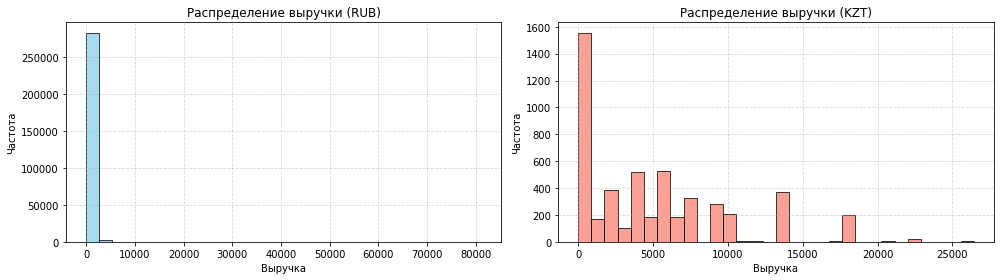

In [19]:
#распределение по полю revenue
revenue_rub = merged_df[merged_df['currency_code'] == 'rub']['revenue']
revenue_kzt = merged_df[merged_df['currency_code'] == 'kzt']['revenue']

#cоздаем фигуру с двумя подграфиками 
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

#график для RUB
axs[0].hist(revenue_rub, bins=30, alpha=0.75, edgecolor='black', color='skyblue')
axs[0].set_title('Распределение выручки (RUB)')
axs[0].set_xlabel('Выручка')
axs[0].set_ylabel('Частота')
axs[0].grid(True, linestyle='--', alpha=0.5)

#график для KZT
axs[1].hist(revenue_kzt, bins=30, alpha=0.75, edgecolor='black', color='salmon')
axs[1].set_title('Распределение выручки (KZT)')
axs[1].set_xlabel('Выручка')
axs[1].set_ylabel('Частота')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Видны выбросы, нужно будет отобрать значения по 99-му процентилю.

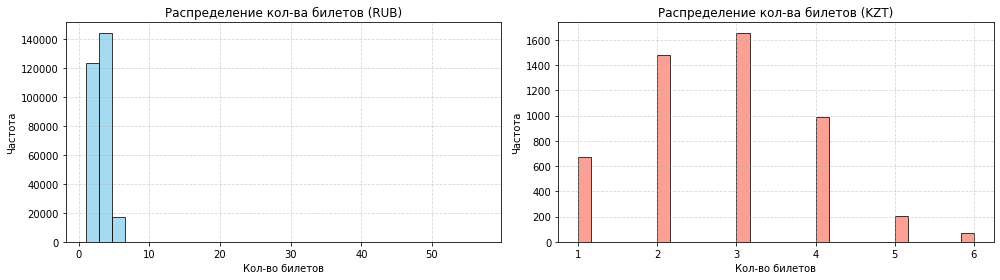

In [20]:
#распределение по полю tickets_count
count_rub = merged_df[merged_df['currency_code'] == 'rub']['tickets_count']
count_kzt = merged_df[merged_df['currency_code'] == 'kzt']['tickets_count']

#cоздаем фигуру с двумя подграфиками 
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

#график для RUB
axs[0].hist(count_rub, bins=30, alpha=0.75, edgecolor='black', color='skyblue')
axs[0].set_title('Распределение кол-ва билетов (RUB)')
axs[0].set_xlabel('Кол-во билетов')
axs[0].set_ylabel('Частота')
axs[0].grid(True, linestyle='--', alpha=0.5)

#график для KZT
axs[1].hist(count_kzt, bins=30, alpha=0.75, edgecolor='black', color='salmon')
axs[1].set_title('Распределение кол-ва билетов (KZT)')
axs[1].set_xlabel('Кол-во билетов')
axs[1].set_ylabel('Частота')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Выбросов нет.

In [21]:
#вернемся к полю revenue - очистим его от выбросов
q99_rub = merged_df[merged_df['currency_code'] == 'rub']['revenue'].quantile(0.99)
q99_kzt = merged_df[merged_df['currency_code'] == 'kzt']['revenue'].quantile(0.99)

mask_rub = (merged_df['currency_code'] == 'rub') & (merged_df['revenue'] > q99_rub)
mask_kzt = (merged_df['currency_code'] == 'kzt') & (merged_df['revenue'] > q99_kzt)

#заменяем выбросы на NaN и удаляем
merged_df.loc[mask_rub, 'revenue'] = np.nan
merged_df.loc[mask_kzt, 'revenue'] = np.nan
merged_df = merged_df.dropna(subset=['revenue'])
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287962 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287962 non-null  int32         
 1   user_id                 287962 non-null  object        
 2   created_dt_msk          287962 non-null  datetime64[ns]
 3   created_ts_msk          287962 non-null  datetime64[ns]
 4   event_id                287962 non-null  int32         
 5   cinema_circuit          287962 non-null  object        
 6   age_limit               287962 non-null  int8          
 7   currency_code           287962 non-null  object        
 8   device_type_canonical   287962 non-null  object        
 9   revenue                 287962 non-null  float32       
 10  service_name            287962 non-null  object        
 11  tickets_count           287962 non-null  int8          
 12  total                   287962

In [22]:
#проверим явные дубликаты
merged_df.duplicated().sum() 

0

In [23]:
#исключаем order_id и days_since_prev из проверки
cols_to_check = [col for col in merged_df.columns if col not in ['order_id', 'days_since_prev']]

duplicate_mask = merged_df.duplicated(subset=cols_to_check, keep=False)
duplicates_df = merged_df[duplicate_mask]

print(f"Найдено неявных дубликатов (без учета days_since_prev): {len(duplicates_df)} строк")

#удаляем дубликаты, оставляя первую запись
merged_df_clean = merged_df.drop_duplicates(subset=cols_to_check, keep='first').copy()

Найдено неявных дубликатов (без учета days_since_prev): 75 строк


In [24]:
#сортируем для корректного сдвига 
merged_df_clean = merged_df_clean.sort_values(by=['user_id', 'created_ts_msk'])

#группируем по пользователю и берем предыдущее значение даты заказа
# shift(1) берет строку выше (предыдущий заказ этого же пользователя)
prev_date = merged_df_clean.groupby('user_id')['created_ts_msk'].shift(1)

#считаем разницу и конвертируем в дни (.dt.days)
#если предыдущей даты нет, будет NaT, вычитание даст NaT, .days вернет NaN
merged_df_clean['days_since_prev_recalc'] = (merged_df_clean['created_ts_msk'] - prev_date).dt.days

#проверка: сравниваем старый и новый столбцы
print("Сравнение старого и нового признака:")
print(merged_df_clean[['days_since_prev', 'days_since_prev_recalc']].head(10))

#старый столбец больше не нужен, его удаляем и переименовываем новый
merged_df_clean.drop(columns=['days_since_prev'], inplace=True)
merged_df_clean.rename(columns={'days_since_prev_recalc': 'days_since_prev'}, inplace=True)


Сравнение старого и нового признака:
   days_since_prev  days_since_prev_recalc
0              NaN                     NaN
1              NaN                     NaN
2             75.0                    74.0
3              NaN                     NaN
4             83.0                    83.0
5             19.0                    18.0
6              NaN                     NaN
7              NaN                     NaN
8             16.0                    15.0
9              NaN                     NaN


In [25]:
#проверим количество order_id с разным содержанием
#группируем по order_id и считаем уникальные комбинации остальных полей
cols_to_check = [col for col in merged_df.columns if col != 'order_id']

grouped = merged_df.groupby('order_id')[cols_to_check].nunique()

#гсли для какого-то order_id nunique > 1 по любому из столбцов - значит, есть расхождения
has_discrepancies = (grouped > 1).any(axis=1)
problematic_orders = grouped[has_discrepancies].index

print(f"Количество order_id с разным содержанием: {len(problematic_orders)}")
print("Примеры проблемных order_id:", problematic_orders[:10].tolist())

Количество order_id с разным содержанием: 0
Примеры проблемных order_id: []


По этому аспекту неявных дубликатов нет.

### Добавление колонок в датафрейм

Добавляем колонку revenue_rub, где будет указана выручка с заказа в рублях для всех заказов, в том числе для заказов в тенге.

In [26]:
#считаем курс
tenge['curs_per_1kzt'] = tenge['curs'] / tenge['nominal']
tenge_clean = tenge[['data', 'curs_per_1kzt']].copy()

#инициализируем колонку в основном датасете
merged_df['revenue_rub'] = merged_df['revenue']

#маска для KZT
kzt_mask = merged_df['currency_code'] == 'kzt'

#берем нужные колонки для временного датафрейма
kzt_temp = merged_df.loc[kzt_mask, ['order_id', 'revenue', 'created_dt_msk']].copy()

#соединяем напрямую по колонкам с датой: created_dt_msk = data
kzt_with_rate = kzt_temp.merge(
    tenge_clean[['data', 'curs_per_1kzt']],
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

#считаем выручку в рублях
kzt_with_rate['revenue_rub_calc'] = kzt_with_rate['revenue'] * kzt_with_rate['curs_per_1kzt']

#обновляем основной датасет 
merged_df.loc[kzt_mask, 'revenue_rub'] = kzt_with_rate['revenue_rub_calc'].values



Добавляем колонку one_ticket_revenue_rub с рассчетом выручки с продажи одного билета на мероприятие.

In [27]:
merged_df['one_ticket_revenue_rub'] = merged_df['revenue'] / merged_df['tickets_count']

Добавляем колонку month — выделияем месяц оформления заказа в отдельный столбец.

In [28]:
merged_df['month'] = merged_df['created_dt_msk'].dt.month

Создаем столбец с информацией о сезонности season включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [29]:
season_map = {
    1: 'зима', 2: 'зима', 3: 'весна',
    4: 'весна', 5: 'весна', 6: 'лето',
    7: 'лето', 8: 'лето', 9: 'осень',
    10: 'осень', 11: 'осень', 12: 'зима'
}

merged_df['season'] = merged_df['month'].map(season_map)


После предобработки проверим, сколько данных отобрали, если выполняли фильтрацию, а также дадим промежуточный вывод с основными действиями и описанием новых столбцов.

In [30]:
merged_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.939941,380.484985,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.450012,144.725006,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.569946,314.642487,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.490000,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.410034,463.470001,10,осень


In [31]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287962 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287962 non-null  int32         
 1   user_id                 287962 non-null  object        
 2   created_dt_msk          287962 non-null  datetime64[ns]
 3   created_ts_msk          287962 non-null  datetime64[ns]
 4   event_id                287962 non-null  int32         
 5   cinema_circuit          287962 non-null  object        
 6   age_limit               287962 non-null  int8          
 7   currency_code           287962 non-null  object        
 8   device_type_canonical   287962 non-null  object        
 9   revenue                 287962 non-null  float32       
 10  service_name            287962 non-null  object        
 11  tickets_count           287962 non-null  int8          
 12  total                   287962

Результаты предобработки:
* Было три датафрейма:<br> 
orders 290849 строк и 14 столбцов<br>
events 22427 строк и 11 столбцов<br>
tenge 357  строк и 4 столбца<br>
* Был создан общий датафрейм:<br>
Сначала объединены orders и events<br>
Затем были исключены выбросы (99 процентиль по полю revenue)<br>
Затем созданы столбцы revenue_rub, one_ticket_revenue_rub, month, season.<br>
* В итоговом датасете merged_df 287962 строк и 28 столбцов.

## Исследовательский анализ данных

###  Анализ распределения заказов по сегментам и их сезонные изменения

Для каждого месяца найдем количество заказов и визуализируем результаты. Проверим, фиксируется ли увеличение заказов от июня к ноябрю 2024 года.

In [32]:
groupped_orders = merged_df.groupby ('month')['order_id'].count()
print(groupped_orders)

month
6     34350
7     40411
8     44579
9     69336
10    99286
Name: order_id, dtype: int64


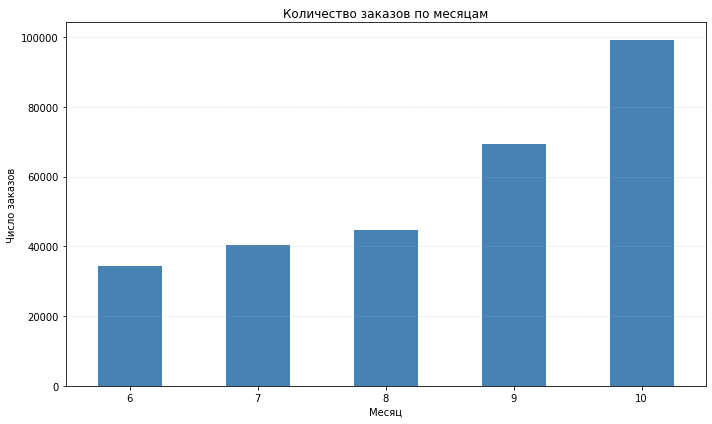

In [33]:
#строим график
plt.figure(figsize=(10, 6))
groupped_orders.plot(kind='bar', color='steelblue')

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.xticks(rotation=0)         
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Наблюдается рост заказов от июня к ноябрю 2024 года.

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Результаты визуализируем подходящим графиком, который поможет сопоставить значения для летнего и осеннего сезонов. Поскольку абсолютное количество заказов в разные сезоны может меняться, при сопоставлении результатов для каждого сегмента используем доли.

Для начала изучим и визуализируем распределение заказов билетов по типу мероприятия.

In [34]:
orders_season_summer_event = (merged_df[merged_df['season'] == 'лето'].groupby('event_type_main')['order_id'].count())
orders_season_fall_event = (merged_df[merged_df['season'] == 'осень'].groupby('event_type_main')['order_id'].count())
total_event_orders = merged_df.groupby('event_type_main')['order_id'].count()
summer_event_ratio = (orders_season_summer_event / total_event_orders) * 100
fall_event_ratio = (orders_season_fall_event / total_event_orders) * 100

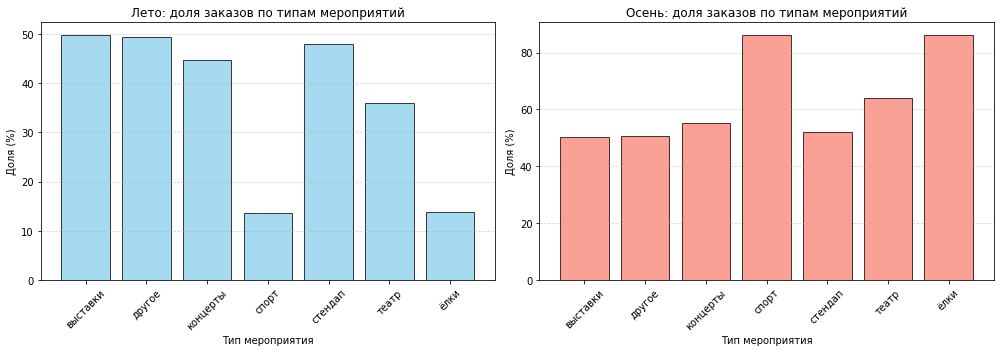

In [35]:
#строим график
#создаем фигуру с двумя подграфиками
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#график для лета
axs[0].bar(
    summer_event_ratio.index,          
    summer_event_ratio.values,         
    alpha=0.75,
    edgecolor='black',
    color='skyblue'
)
axs[0].set_title('Лето: доля заказов по типам мероприятий')
axs[0].set_xlabel('Тип мероприятия')
axs[0].set_ylabel('Доля (%)')
axs[0].tick_params(axis='x', rotation=45)  # поворот подписей
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

#график для осени
axs[1].bar(
    fall_event_ratio.index,
    fall_event_ratio.values,
    alpha=0.75,
    edgecolor='black',
    color='salmon'
)
axs[1].set_title('Осень: доля заказов по типам мероприятий')
axs[1].set_xlabel('Тип мероприятия')
axs[1].set_ylabel('Доля (%)')
axs[1].tick_params(axis='x', rotation=45)
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* Летом одинаково много заказов по выставкам, концертам, стендапу и категории другое. Мало по спорту и елкам (логично).
* Осенью наоборот много заказов по спорту и ёлкам.

Изучим и визуализируем распределение заказов билетов по типу устройства.

In [36]:
orders_season_summer_device = (merged_df[merged_df['season'] == 'лето'].groupby('device_type_canonical')['order_id'].count())
orders_season_fall_device = (merged_df[merged_df['season'] == 'осень'].groupby('device_type_canonical')['order_id'].count())
total_device_orders = merged_df.groupby('device_type_canonical')['order_id'].count()
summer_device_ratio = (orders_season_summer_device / total_device_orders) * 100
fall_device_ratio = (orders_season_fall_device / total_device_orders) * 100

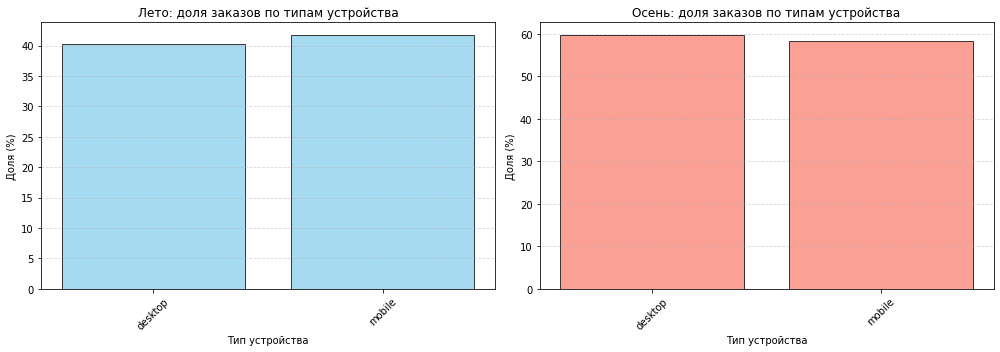

In [37]:
#строим график
#создаем фигуру с двумя подграфиками
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#график для лета
axs[0].bar(
    summer_device_ratio.index,          
    summer_device_ratio.values,         
    alpha=0.75,
    edgecolor='black',
    color='skyblue'
)
axs[0].set_title('Лето: доля заказов по типам устройства')
axs[0].set_xlabel('Тип устройства')
axs[0].set_ylabel('Доля (%)')
axs[0].tick_params(axis='x', rotation=45)  # поворот подписей
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

#график для осени
axs[1].bar(
    fall_device_ratio.index,
    fall_device_ratio.values,
    alpha=0.75,
    edgecolor='black',
    color='salmon'
)
axs[1].set_title('Осень: доля заказов по типам устройства')
axs[1].set_xlabel('Тип устройства')
axs[1].set_ylabel('Доля (%)')
axs[1].tick_params(axis='x', rotation=45)
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* Летом чуть больше заказов в мобильных утройств.
* Осенью чуть больше заказов с ПК.

Изучим и визуализируем распределение заказов билетов по возрастному рейтингу.

In [38]:
orders_season_summer_age = (merged_df[merged_df['season'] == 'лето'].groupby('age_limit')['order_id'].count())
orders_season_fall_age = (merged_df[merged_df['season'] == 'осень'].groupby('age_limit')['order_id'].count())
total_age_orders = merged_df.groupby('age_limit')['order_id'].count()
summer_age_ratio = (orders_season_summer_age / total_age_orders) * 100
fall_age_ratio = (orders_season_fall_age / total_age_orders) * 100

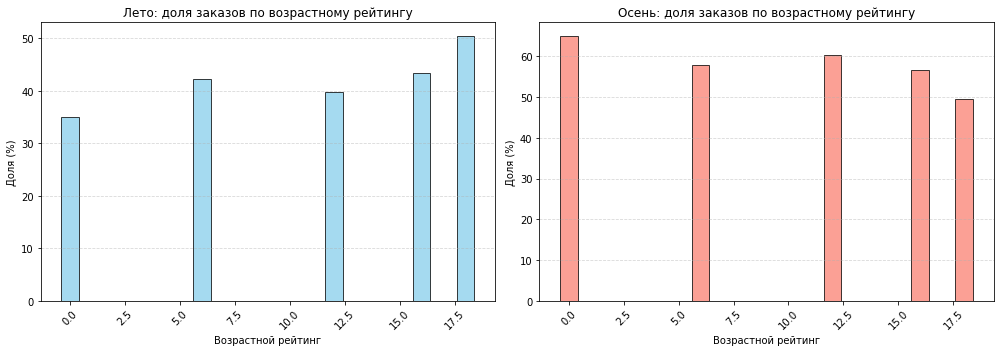

In [39]:
#строим график
#создаем фигуру с двумя подграфиками
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#график для лета
axs[0].bar(
    summer_age_ratio.index,          
    summer_age_ratio.values,         
    alpha=0.75,
    edgecolor='black',
    color='skyblue'
)
axs[0].set_title('Лето: доля заказов по возрастному рейтингу')
axs[0].set_xlabel('Возрастной рейтинг')
axs[0].set_ylabel('Доля (%)')
axs[0].tick_params(axis='x', rotation=45)  # поворот подписей
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

#график для осени
axs[1].bar(
    fall_age_ratio.index,
    fall_age_ratio.values,
    alpha=0.75,
    edgecolor='black',
    color='salmon'
)
axs[1].set_title('Осень: доля заказов по возрастному рейтингу')
axs[1].set_xlabel('Возрастной рейтинг')
axs[1].set_ylabel('Доля (%)')
axs[1].tick_params(axis='x', rotation=45)
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* Летом больше заказов с рейтингом 18+
* Осенью больше заказов с рейтингом 0+

Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. Ответим на вопрос - видна ли динамика средней выручки с заказа билета в разрезе разных категорий мероприятий? Для каждого типа мероприятия рассчитаем среднее значение выручки с одного билета, затем найдем относительное изменение осенних значений по сравнению с летними. Результат сопроводим подходящей визуализацией.

Для начала посчитаем среднюю выручку с продажи одного билета в разрезе категории мероприятия летом и осенью и визуализируем.

In [40]:
revenue_event_summer = (merged_df[merged_df['season'] == 'лето'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()
.sort_values(ascending=False))
revenue_event_fall = (merged_df[merged_df['season'] == 'осень'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()
.sort_values(ascending=False))

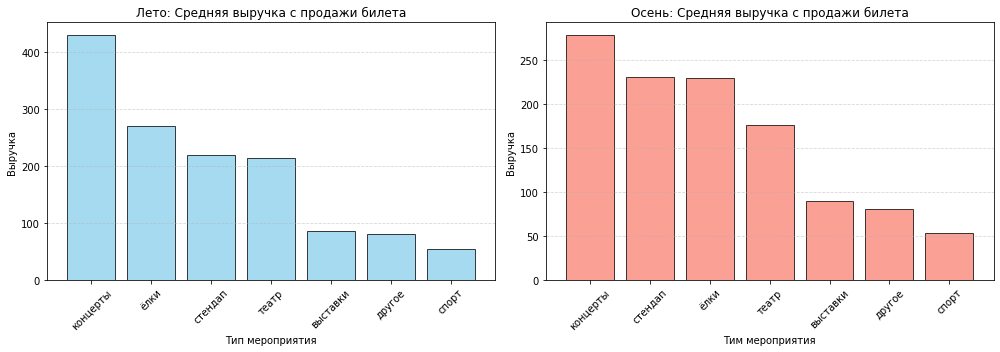

In [41]:
#строим график
#создаем фигуру с двумя подграфиками
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#график для лета
axs[0].bar(
    revenue_event_summer.index,           
    revenue_event_summer.values,         
    alpha=0.75,
    edgecolor='black',
    color='skyblue'
)
axs[0].set_title('Лето: Средняя выручка с продажи билета')
axs[0].set_xlabel('Тип мероприятия')
axs[0].set_ylabel('Выручка')
axs[0].tick_params(axis='x', rotation=45)  # поворот подписей
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

#график для осени
axs[1].bar(
    revenue_event_fall.index,
    revenue_event_fall.values,
    alpha=0.75,
    edgecolor='black',
    color='salmon'
)
axs[1].set_title('Осень: Средняя выручка с продажи билета')
axs[1].set_xlabel('Тим мероприятия')
axs[1].set_ylabel('Выручка')
axs[1].tick_params(axis='x', rotation=45)
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Найдем относительное изменение осенних значений по сравнению с летними.

In [42]:
# выравниваем индексы: чтобы на обоих рядах были одни и те же категории в одном порядке

all_categories = revenue_event_summer.index.union(revenue_event_fall.index)
summer_aligned = revenue_event_summer.reindex(all_categories, fill_value=0)
fall_aligned = revenue_event_fall.reindex(all_categories, fill_value=0)

#считаем относительное изменение

relative_change = ((fall_aligned - summer_aligned) / summer_aligned) * 100
relative_change = relative_change.round(2)

#DataFrame с округленными значениями выручки
result_df = pd.DataFrame({
    'Лето (средняя выручка)': summer_aligned.round(2),
    'Осень (средняя выручка)': fall_aligned.round(2),
    'Изменение (%)': relative_change
})

#настраиваем отображение таблицы
pd.set_option('display.float_format', '{:.2f}'.format)
print(result_df)

                 Лето (средняя выручка)  Осень (средняя выручка)  \
event_type_main                                                    
выставки                          86.39                    90.60   
другое                            81.98                    80.46   
концерты                         430.63                   278.83   
спорт                             55.17                    53.92   
стендап                          219.07                   231.12   
театр                            214.19                   175.96   
ёлки                             271.44                   229.59   

                 Изменение (%)  
event_type_main                 
выставки                  4.88  
другое                   -1.85  
концерты                -35.25  
спорт                    -2.27  
стендап                   5.50  
театр                   -17.85  
ёлки                    -15.42  


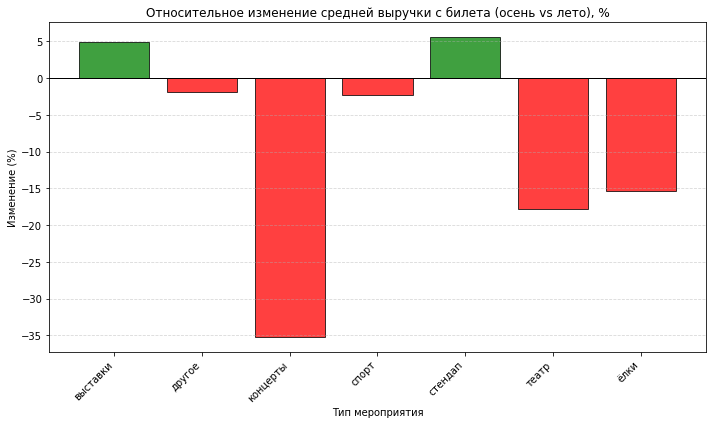

In [43]:
#строим график, используя
plt.figure(figsize=(10, 6))  

colors = ['green' if x >= 0 else 'red' for x in relative_change.values]

plt.bar(
    relative_change.index,
    relative_change.values,
    color=colors,
    alpha=0.75,
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Относительное изменение средней выручки с билета (осень vs лето), %')
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Сильнее всего упала выручка с продаж билетов на концерты - на 35.57%.

### Осенняя активность пользователей

Изучитим активность пользователей за два осенних месяца.
Проанализируем динамику изменений по дням для:
* общего числа заказов;
* количества активных пользователей DAU;
* среднего числа заказов на одного пользователя;
* средней стоимости одного билета.

In [44]:
#общее число заказов
total_daily_orders = (merged_df[merged_df['season'] == 'осень'].groupby('created_dt_msk')['order_id'].nunique())
#количества активных пользователей DAU
dau = (merged_df[merged_df['season'] == 'осень'].groupby('created_dt_msk')['user_id'].nunique())
#среднее число заказов на одного пользователя
avg_orders_per_user = (merged_df[merged_df['season'] == 'осень'].groupby('created_dt_msk')
                       .apply(lambda x: x['order_id'].count() / x['user_id'].nunique()))
#средняя стоимость одного билета
avg_ticket_cost = (merged_df[merged_df['season'] == 'осень'].groupby('created_dt_msk')
                       .apply(lambda x: x['total'].sum() / x['tickets_count'].sum()))
#делаем сводную таблицу
summary_df = pd.DataFrame({
    'total_daily_orders': total_daily_orders,
    'dau': dau,
    'avg_orders_per_user': avg_orders_per_user,
    'avg_ticket_cost': avg_ticket_cost
})
print(summary_df)

                total_daily_orders   dau  avg_orders_per_user  avg_ticket_cost
created_dt_msk                                                                
2024-09-01                    1327   564                 2.35          2290.28
2024-09-02                    1380   574                 2.40          2523.45
2024-09-03                    5111   778                 6.57          1344.48
2024-09-04                    1773   685                 2.59          2482.87
2024-09-05                    1944   739                 2.63          2605.30
...                            ...   ...                  ...              ...
2024-10-27                    2849  1034                 2.76          2227.39
2024-10-28                    2839   985                 2.88          2024.78
2024-10-29                    2836   998                 2.84          2046.44
2024-10-30                    2929  1040                 2.82          2249.99
2024-10-31                    5962  1272            

Визуализируем метрики:
* Общее число заказов.
* DAU.
* Среднее число заказов на одного пользователя.
* Средняя стоимость одного билета.

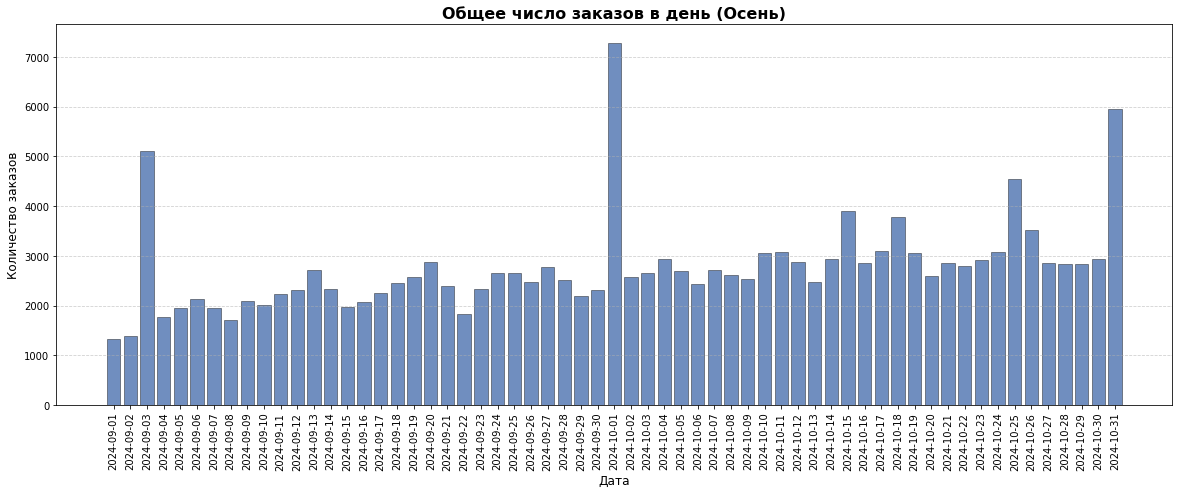

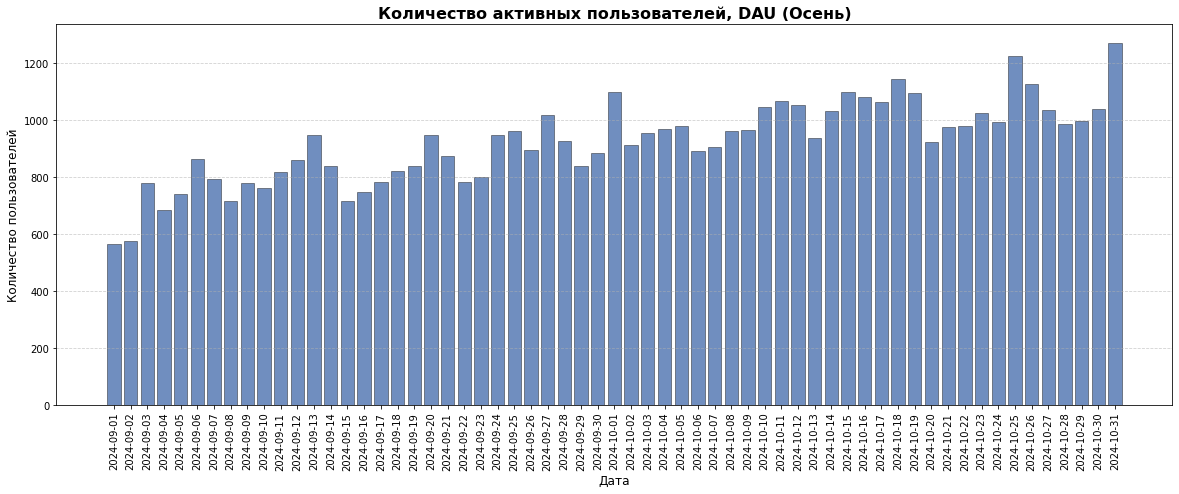

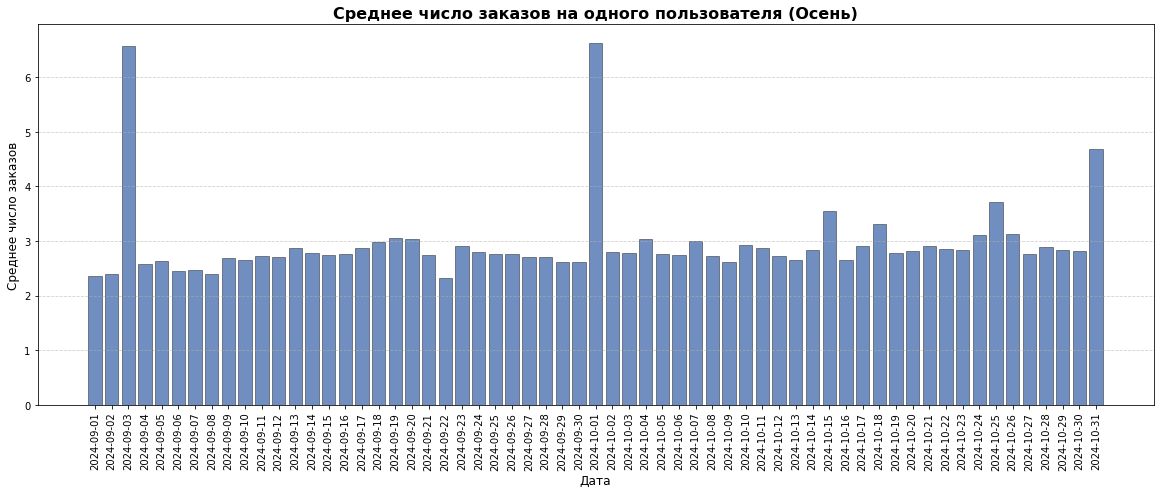

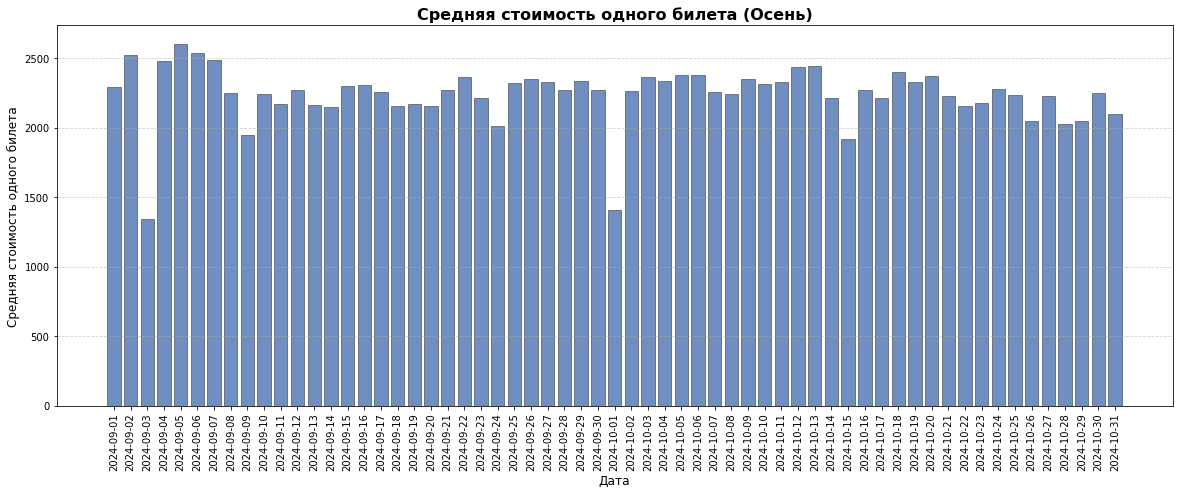

In [45]:
#рисуем график общее число заказов

dates = pd.to_datetime(total_daily_orders.index).strftime('%Y-%m-%d')
values = total_daily_orders.values

plt.figure(figsize=(20, 7)) 

plt.bar(dates, values, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.5)

plt.title('Общее число заказов в день (Осень)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=90)

plt.show()

#рисуем график количества активных пользователей DAU
dates = pd.to_datetime(dau.index).strftime('%Y-%m-%d')
values = dau.values

plt.figure(figsize=(20, 7)) 

plt.bar(dates, values, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.5)

plt.title('Количество активных пользователей, DAU (Осень)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=90)

plt.show()

#рисуем график среднее число заказов на одного пользователя

dates = pd.to_datetime(avg_orders_per_user.index).strftime('%Y-%m-%d')
values = avg_orders_per_user.values

plt.figure(figsize=(20, 7)) 

plt.bar(dates, values, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.5)

plt.title('Среднее число заказов на одного пользователя (Осень)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Среднее число заказов', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=90)

plt.show()

#рисуем график средняя стоимость одного билета

dates = pd.to_datetime(avg_ticket_cost.index).strftime('%Y-%m-%d')
values = avg_ticket_cost.values

plt.figure(figsize=(20, 7)) 

plt.bar(dates, values, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.5)

plt.title('Средняя стоимость одного билета (Осень)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Средняя стоимость одного билета', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=90)

plt.show()

* Общее число заказов в день: тут мы видим 3 сентября, 1 октября, 31 октября довольно высокие показатели. Возможно, они связаны с акциями или другими маркетинговыми активностями.
* DAU: имеет небольшие колебания, но без резких ростов и провалов, довольно стабильный показатель.
* Среднее число заказов на пользователя: видим высокие показатели 3 сентября, 1 октября, 31 октября как и на первом графике с числом заказов в день. Метрики между собой связаны. 
* Средняя стоимость одного билета: 3 сентября, 1 октября она самая низкая, значит были акции и скидки, которые привели к росту числа заказов в эти даты, но 31 октября стоимость билета не сильно отличается от остальных дней.

Изучим недельную цикличность. Выделим день недели и сравним пользовательскую активность в будни и выходные.

In [46]:
#создаем признак дня недели и типа дня
merged_df['day_of_week'] = merged_df['created_dt_msk'].dt.day_name()
day_map = {
    'Monday': 'Будни',
    'Tuesday': 'Будни',
    'Wednesday': 'Будни',
    'Thursday': 'Будни',
    'Friday': 'Будни',
    'Saturday': 'Выходные',
    'Sunday': 'Выходные'
}
merged_df['week_type'] = merged_df['day_of_week'].map(day_map)

#фильтруем данные заранее для читаемости кода
df_autumn = merged_df[merged_df['season'] == 'осень']

#агрегируем по суткам
daily_agg = df_autumn.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'nunique'),
    dau=('user_id', 'nunique'),
).reset_index()

#добавим день недели к суточной таблице, чтобы группировать дальше
daily_agg['day_of_week'] = daily_agg['created_dt_msk'].dt.day_name()
daily_agg['week_type'] = daily_agg['day_of_week'].map(day_map)

#считаем дополнительные метрики для каждого дня отдельно, чтобы потом усреднить их по дням недели

def calc_daily_metrics(group):
    """Считает метрики для одного конкретного дня"""
    total_ord = group['order_id'].nunique()
    dau = group['user_id'].nunique()
    
    #среднее число заказов на пользователя за день
    avg_ord_per_user = group['order_id'].count() / dau if dau > 0 else 0
    
    #средняя стоимость билета за день
    total_sum = group['total'].sum()
    tickets_sum = group['tickets_count'].sum()
    avg_ticket = total_sum / tickets_sum if tickets_sum > 0 else 0
    
    return pd.Series({
        'total_orders_day': total_ord,
        'dau_day': dau,
        'avg_orders_per_user_day': avg_ord_per_user,
        'avg_ticket_cost_day': avg_ticket
    })

#применяем функцию к каждому дню
daily_metrics = df_autumn.groupby('created_dt_msk').apply(calc_daily_metrics).reset_index()

#добавляем день недели и тип недели обратно
daily_metrics['day_of_week'] = daily_metrics['created_dt_msk'].dt.day_name()
daily_metrics['week_type'] = daily_metrics['day_of_week'].map(day_map)

#усредняем полученные суточные метрики по дням недели

#общее число заказов
total_workdays_orders = daily_metrics[daily_metrics['week_type'] == 'Будни'].groupby('day_of_week')['total_orders_day'].mean()
total_weekends_orders = daily_metrics[daily_metrics['week_type'] == 'Выходные'].groupby('day_of_week')['total_orders_day'].mean()

#DAU 
dau_workdays = daily_metrics[daily_metrics['week_type'] == 'Будни'].groupby('day_of_week')['dau_day'].mean()
dau_weekends = daily_metrics[daily_metrics['week_type'] == 'Выходные'].groupby('day_of_week')['dau_day'].mean()

#среднее число заказов на одного пользователя
avg_orders_per_user_workdays = daily_metrics[daily_metrics['week_type'] == 'Будни'].groupby('day_of_week')['avg_orders_per_user_day'].mean()
avg_orders_per_user_weekends = daily_metrics[daily_metrics['week_type'] == 'Выходные'].groupby('day_of_week')['avg_orders_per_user_day'].mean()

#средняя стоимость одного билета 
avg_ticket_cost_workdays = daily_metrics[daily_metrics['week_type'] == 'Будни'].groupby('day_of_week')['avg_ticket_cost_day'].mean()
avg_ticket_cost_weekends = daily_metrics[daily_metrics['week_type'] == 'Выходные'].groupby('day_of_week')['avg_ticket_cost_day'].mean()

#делаем сводные таблицы 
summary_df_workdays = pd.DataFrame({
    'total_workdays_orders': total_workdays_orders, 
    'dau_workdays': dau_workdays,
    'avg_orders_per_user_workdays': avg_orders_per_user_workdays,
    'avg_ticket_cost_workdays': avg_ticket_cost_workdays
})
print(summary_df_workdays)

print('---------------------------------------------------')

summary_df_weekends = pd.DataFrame({
    'total_weekends_orders': total_weekends_orders,
    'dau_weekends': dau_weekends,
    'avg_orders_per_user_weekends': avg_orders_per_user_weekends,
    'avg_ticket_cost_weekends': avg_ticket_cost_weekends
})
print(summary_df_weekends)


             total_workdays_orders  dau_workdays  \
day_of_week                                        
Friday                     3103.62       1022.62   
Monday                     2391.00        853.89   
Thursday                   3018.89        962.11   
Tuesday                    3498.11        934.22   
Wednesday                  2543.56        923.22   

             avg_orders_per_user_workdays  avg_ticket_cost_workdays  
day_of_week                                                          
Friday                               3.00                   2311.08  
Monday                               2.78                   2219.76  
Thursday                             3.06                   2295.92  
Tuesday                              3.72                   1959.92  
Wednesday                            2.75                   2271.95  
---------------------------------------------------
             total_weekends_orders  dau_weekends  \
day_of_week                              

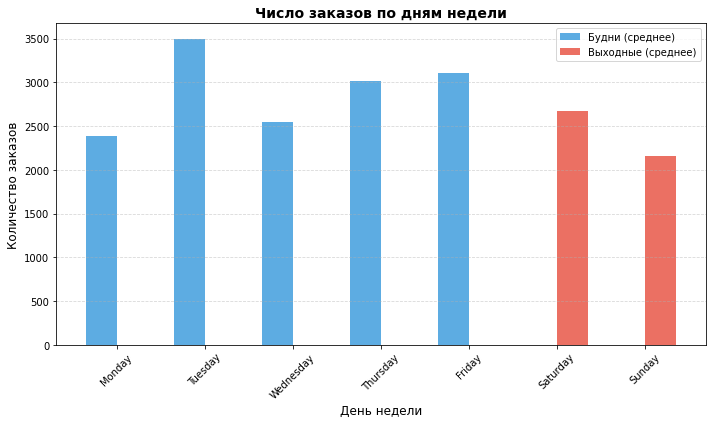

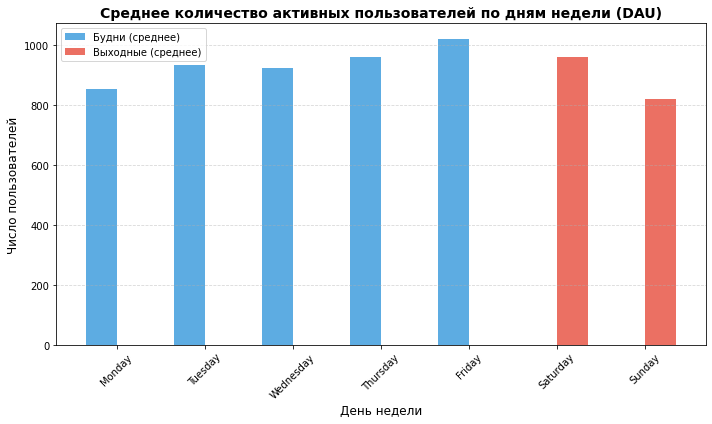

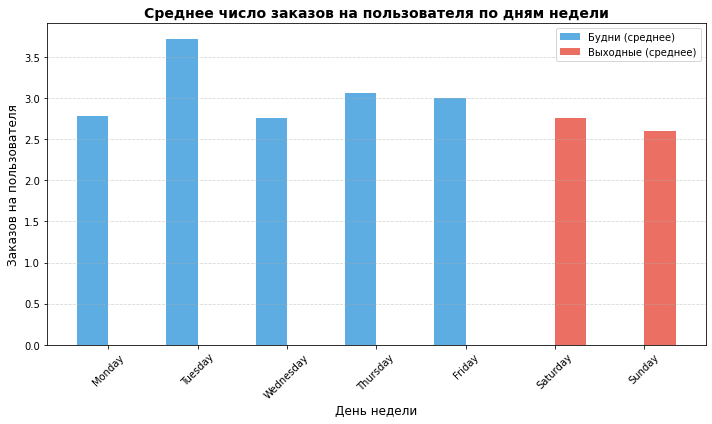

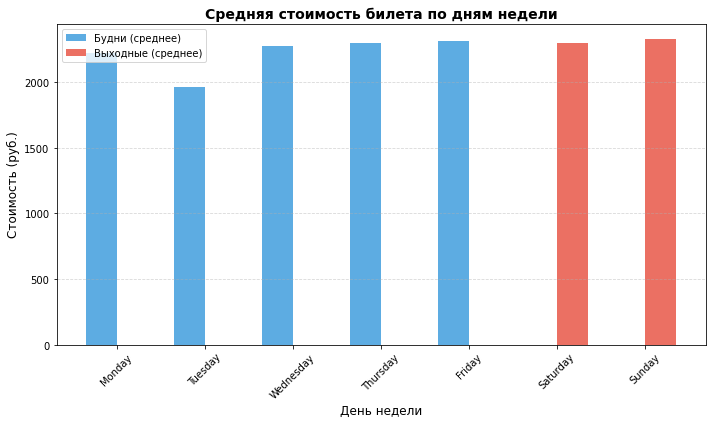

In [47]:
#рисуем график
#создаем общий индекс из всех дней недели
all_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#функция для построения одного графика
def plot_metric(work_series, weekend_series, title, ylabel, color_work='#3498db', color_weekend='#e74c3c'):
    plt.figure(figsize=(10, 6))
    
    #создаем DataFrame с полным набором дней, чтобы порядок был одинаковым
    df_plot = pd.DataFrame(index=all_days)
    df_plot['work'] = work_series
    df_plot['weekend'] = weekend_series
    
    #индексы для столбцов
    x = range(len(all_days))
    width = 0.35
    
    #рисуем столбцы
    plt.bar([i - width/2 for i in x], df_plot['work'].fillna(0), width, label='Будни (среднее)', color=color_work, alpha=0.8)
    plt.bar([i + width/2 for i in x], df_plot['weekend'].fillna(0), width, label='Выходные (среднее)', color=color_weekend, alpha=0.8)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('День недели', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(x, all_days, rotation=45) # Подписи дней недели
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

#общее число заказов
plot_metric(
    total_workdays_orders, 
    total_weekends_orders, 
    'Число заказов по дням недели', 
    'Количество заказов'
)

#DAU
plot_metric(
    dau_workdays, 
    dau_weekends, 
    'Среднее количество активных пользователей по дням недели (DAU)', 
    'Число пользователей'
)

#среднее число заказов на пользователя
plot_metric(
    avg_orders_per_user_workdays, 
    avg_orders_per_user_weekends, 
    'Среднее число заказов на пользователя по дням недели', 
    'Заказов на пользователя'
)

#средняя стоимость билета
plot_metric(
    avg_ticket_cost_workdays, 
    avg_ticket_cost_weekends, 
    'Средняя стоимость билета по дням недели', 
    'Стоимость (руб.)'
)


* Общее число заказов больше всего во вторник, меньше всего в воскресение.
* DAU в течение недели относительно стабильно, но можно сказать, что он растет к пятнице и падает к воскресению.
* Среднее число заказов на пользователя больше всего во вторник, меньше всего в воскресение.
* Средняя стоимость билета относительно одинакова все дни, кроме вторника.

### Популярные события и партнёры

Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов. Ответим на вопрос - в каких регионах предлагается наибольшее разнообразие мероприятий? <br>
Исследуйте не только абсолютные значения, но и доли. Например, для каждого региона посчитаем долю проводимых мероприятий от их общего числа или долю заказов в регионе от общего числа заказов.

In [48]:
#для каждого региона посчитаем уникальное количество мероприятий
#абсолютное значение
events_for_regions = merged_df.groupby('region_name')['event_id'].nunique().sort_values(ascending = False)
print(events_for_regions)

region_name
Каменевский регион          5935
Североярская область        3800
Широковская область         1232
Светополянский округ        1075
Речиновская область          702
                            ... 
Теплоозёрский округ            2
Сосноводолинская область       2
Лесноярский край               2
Светолесский край              2
Верхозёрский край              2
Name: event_id, Length: 81, dtype: int64


In [49]:
#для каждого региона посчитаем долю проводимых мероприятий от их общего числа
total_events = merged_df['event_id'].nunique()
events_ratio = (events_for_regions / total_events) * 100
print(events_ratio)

region_name
Каменевский регион         26.52
Североярская область       16.98
Широковская область         5.51
Светополянский округ        4.80
Речиновская область         3.14
                            ... 
Теплоозёрский округ         0.01
Сосноводолинская область    0.01
Лесноярский край            0.01
Светолесский край           0.01
Верхозёрский край           0.01
Name: event_id, Length: 81, dtype: float64


Каменевский регион проводит большее количество мероприятий - 5935 или 26.52% от общего числа.

In [50]:
#для каждого региона посчитаем общее число заказов
orders_for_regions = merged_df.groupby('region_name')['order_id'].nunique().sort_values(ascending = False)
print(orders_for_regions)

region_name
Каменевский регион          89674
Североярская область        43744
Широковская область         16169
Медовская область           13895
Озернинский край            10348
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: order_id, Length: 81, dtype: int64


In [51]:
#для каждого региона посчитаем долю заказов от их общего числа
total_orders = merged_df['order_id'].nunique()
orders_ratio = (orders_for_regions / total_orders) * 100
print(orders_ratio)

region_name
Каменевский регион         31.14
Североярская область       15.19
Широковская область         5.61
Медовская область           4.83
Озернинский край            3.59
                            ... 
Лесноярский край            0.01
Крутоводский регион         0.01
Верхозёрский край           0.00
Сосноводолинская область    0.00
Теплоозёрский округ         0.00
Name: order_id, Length: 81, dtype: float64


В Каменевском районе более количество заказов - 89665 или 31.14% от общего числа.

Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Сделаем акцент на наиболее активных партнёрах.

In [52]:
#общее число уникальных мероприятий для каждого билетного партнера
events_for_service_partner = merged_df.groupby('service_name')['event_id'].nunique().sort_values(ascending = False)
print(events_for_service_partner)

service_name
Лови билет!               4869
Билеты без проблем        4255
Билеты в руки             3536
Облачко                   2335
Лучшие билеты             1763
Мой билет                 1302
Тебе билет!               1062
Прачечная                 1026
Весь в билетах             855
Яблоко                     714
Городской дом культуры     378
Show_ticket                295
Дом культуры               272
Crazy ticket!              256
Быстробилет                255
Край билетов               252
За билетом!                235
Мир касс                   192
Выступления.ру             147
Восьмёрка                  143
Росбилет                    60
КарандашРУ                  46
Вперёд!                     37
Телебилет                   24
Быстрый кассир              20
Билет по телефону           20
Цвет и билет                18
Шоу начинается!             11
Радио ticket                 8
Реестр                       7
Лимоны                       4
Тех билет                 

Больше всего мероприятий у Лови билет! - 4869 шт.

In [53]:
#общее число обработанных заказов для каждого билетного партнера
orders_for_service_partner = merged_df.groupby('service_name')['order_id'].nunique().sort_values(ascending = False)
print(orders_for_service_partner)

service_name
Билеты без проблем        63035
Лови билет!               40806
Билеты в руки             40307
Мой билет                 34447
Облачко                   26402
Лучшие билеты             17763
Весь в билетах            16410
Прачечная                 10222
Край билетов               6109
Тебе билет!                5178
Яблоко                     5004
Дом культуры               4412
За билетом!                2855
Городской дом культуры     2727
Мир касс                   2137
Show_ticket                2090
Быстробилет                1983
Выступления.ру             1590
Восьмёрка                  1106
Crazy ticket!               789
Шоу начинается!             460
Росбилет                    395
Быстрый кассир              379
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      124
Билет по телефону            85
Вперёд!                      80
Дырокол                      70
Кино билет                 

Самое большое количество заказов у Билеты без проблем - 63022. Лидер предыдущего рейтинга Лови билет! на втаром месте с числом 40802 заказов.

In [54]:
#посчитаем суммарную выручку с заказов для каждого билетного партнёра
revenue_for_service_partner = merged_df.groupby('service_name')['revenue_rub'].sum().sort_values(ascending = False)
print(revenue_for_service_partner)

service_name
Билеты без проблем       24261552.00
Мой билет                22044402.00
Облачко                  18588614.00
Лови билет!              16670921.00
Весь в билетах           16494669.00
Билеты в руки            13197464.00
Край билетов              6405689.00
Прачечная                 4746810.50
Дом культуры              4358656.00
Яблоко                    3868337.00
Тебе билет!               2928923.50
Лучшие билеты             2721777.50
За билетом!               2036077.25
Мир касс                  1836968.00
Городской дом культуры    1641318.38
Быстробилет               1533526.12
Show_ticket               1449276.38
Выступления.ру            1218604.75
Восьмёрка                  657809.25
Росбилет                   514513.38
Шоу начинается!            463641.19
Crazy ticket!              451924.81
Быстрый кассир             396689.94
Телебилет                  187322.66
Дырокол                    104077.95
Радио ticket                81893.24
Билет по телефону        

Здесь также лидирует Билеты без проблем - 2 425 5352 руб

Итог: явный лидер среди регионов - Каменевский район. Среди партнеров лидируют Билеты без проблем и Лови билет! 

## Статистический анализ данных

Тестируем гипотезу о том, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. Данные берем только за осень.

* Анализируем количественные дискретные данные - количество заказов, сделанных каждым уникальным пользователем (user_id) за осенний сезон с конкретного типа устройства (mobile/desktop).
* Единица наблюдения - среднее число заказов на пользователя.
* Наблюдения ниже рассчитаны как независимые, посчитано среднее кол-во заказов на пользователя так, чтобы в обеих выборках присутствовали все пользователи, включая тех, у кого по одному из устройств количество заказов равно нулю. Один и тот же пользователь мог сделать заказ и с ПК и через приложение.
* Будем проверять, существует ли систематический перекос в количестве заказов между мобильными и десктопными устройствами.

In [55]:
#считаем метрики, берем отфильтрованный ранее датафрейм df_autumn с заказами за осень
#создаем сводную таблицу: сколько заказов сделал каждый пользователь с каждого устройства
user_device_pivot = df_autumn.pivot_table(
    index='user_id', 
    columns='device_type_canonical', 
    values='order_id', 
    aggfunc='count', 
    fill_value=0  # заменяет NaN на 0 для пользователей, не использовавших устройство
)

#считаем средние, обращаясь к колонкам этой сводной таблицы.
#если у пользователя не было мобильных заказов, он попадет в расчет со значением 0

#среднее число заказов на одного пользователя моб.приложения
if 'mobile' in user_device_pivot.columns:
    avg_orders_per_user_mobile = user_device_pivot['mobile'].mean()
else:
    avg_orders_per_user_mobile = 0

#среднее число заказов на одного пользователя ПК
if 'desktop' in user_device_pivot.columns:
    avg_orders_per_desktop = user_device_pivot['desktop'].mean()
else:
    avg_orders_per_desktop = 0

print(f'Среднее число заказов на одного пользователя приложения: {avg_orders_per_user_mobile:.2f}')
print(f'Среднее число заказов на одного пользователя ПК: {avg_orders_per_desktop:.2f}')

# Для проверки можно выводим размер выборки (общее кол-во уникальных пользователей в сезоне)
total_users_in_season = len(user_device_pivot)
print(f"Всего уникальных пользователей в выборке: {total_users_in_season}")


Среднее число заказов на одного пользователя приложения: 8.50
Среднее число заказов на одного пользователя ПК: 2.17
Всего уникальных пользователей в выборке: 15809


Проверим распеределениие метрик.

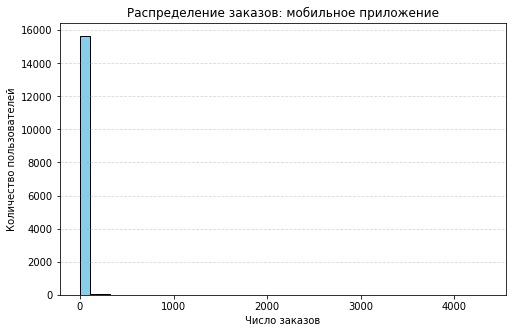

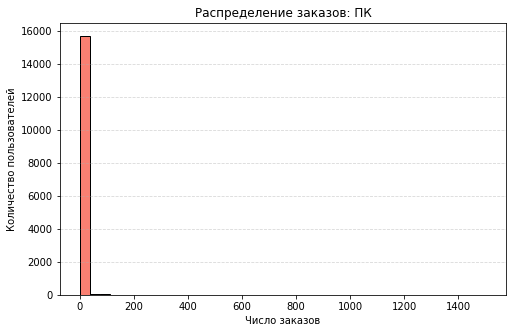

In [56]:
#гистограмма для мобильных заказов
plt.figure(figsize=(8, 5))
plt.hist(user_device_pivot['mobile'], bins=40, color='skyblue', edgecolor='black')
plt.title('Распределение заказов: мобильное приложение')
plt.xlabel('Число заказов')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#гистограмма для ПК
plt.figure(figsize=(8, 5))
plt.hist(user_device_pivot['desktop'], bins=40, color='salmon', edgecolor='black')
plt.title('Распределение заказов: ПК')
plt.xlabel('Число заказов')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


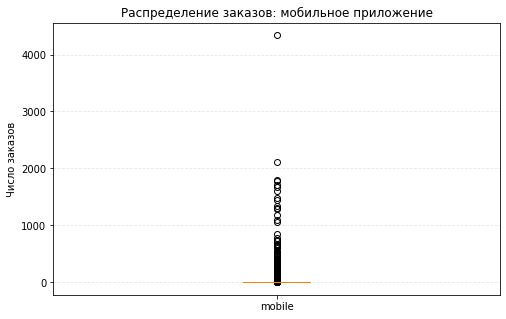

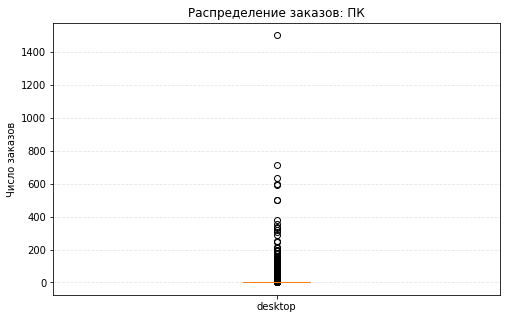

In [57]:
#ящик с усами для мобильных заказов
plt.figure(figsize=(8, 5))
plt.boxplot(user_device_pivot['mobile'], vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Распределение заказов: мобильное приложение')
plt.ylabel('Число заказов')
plt.xticks([1], ['mobile'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#ящик с усами для ПК
plt.figure(figsize=(8, 5))
plt.boxplot(user_device_pivot['desktop'], vert=True, patch_artist=True, boxprops=dict(facecolor='salmon'))
plt.title('Распределение заказов: ПК')
plt.ylabel('Число заказов')
plt.xticks([1], ['desktop'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


Распределения не являются нормальными, медиана в районе нуля, есть большие выбросы. Удалять их не следует, потому что тогда исказится картина - могут быть перекупы или например корпоративные клиенты, которые заказываеют очень много билетов и есть простые пользователи, которые заказывают мало.

* Нулевая гипотеза: среднее количество заказов на одного пользователя мобильного приложения аналогичное по сравнению с пользователями стационарных устройств или ниже.
* Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств и это статистически значимо.

Так как на графиках выше видны выбросы, проверим гипотезы критерием Уилкоксона - отличается ли распределение попарных разностей от нуля, то есть, чаще ли значения в одной группе больше, чем в другой. Также проверим достаточно ли данных для теста.

In [58]:
#проверим гипотезы тестом Уилкоксона 

#разность: mobile - desktop для каждого пользователя
diff = user_device_pivot['mobile'] - user_device_pivot['desktop']

#исключаем нулевые разности (если пользователь не делал заказов ни с одного устройства)
diff_nonzero = diff[diff != 0]

#проверка: достаточно ли данных для теста
if len(diff_nonzero) < 10:
    print("Предупреждение: слишком мало ненулевых разностей для надёжного теста.")
else:
    stat, p_val = wilcoxon(diff_nonzero)
    print(f"Wilcoxon signed-rank test: statistic={stat:.2f}, p-value={p_val:.4f}")

    
    alpha = 0.05

    mean_diff = diff.mean()
    
    if p_val / 2 < alpha and mean_diff > 0:
        conclusion = "Подтверждена альтернативная гипотеза: с мобильного приложения пользователи делают больше заказов, чем с ПК."
        print(conclusion)
    elif p_val / 2 < alpha and mean_diff < 0:
        conclusion = "Подтверждена альтернативная гипотеза: с ПК пользователи делают больше заказов, чем с мобильного."
        print(conclusion)
    else:
        conclusion = "Не удалось отвергнуть нулевую гипотезу: нет оснований утверждать, что количество заказов отличается между устройствами."
        print(conclusion)

    
    print(f"Средняя разность (mobile - desktop): {mean_diff:.3f} заказов")
    print(f"Медианная разность (mobile - desktop): {np.median(diff):.3f} заказов")
    print(f"Доля пользователей, у которых mobile > desktop: {(diff > 0).mean():.2%}")


Wilcoxon signed-rank test: statistic=13255046.50, p-value=0.0000
Подтверждена альтернативная гипотеза: с мобильного приложения пользователи делают больше заказов, чем с ПК.
Средняя разность (mobile - desktop): 6.326 заказов
Медианная разность (mobile - desktop): 1.000 заказов
Доля пользователей, у которых mobile > desktop: 83.78%


Следующим шагом тестируем другую гипотезу - среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств. Данные берем только за осень.

* Анализируем непрерывные количественные данные - интервал в днях.
* Единица наблюдения - среднее время между заказами.
* Наблюдения посчитаны как независимые, выделены сегменты преимущественно мобильные, десктопные, смешанные. Один и тот же пользователь мог сделать заказ и с ПК и через приложение, но в расчете один пользователь в одном сегменте.
* Будем считать средний интервал между заказами для каждого пользователя и сравнить полученные пользовательские средние между группами, на основании чего сделаем вывод - у какой группы больше средний интервал между заказами.
* Также нам не нужны пропуски в данных. При наличии их нужно удалить, ведь мы анализируем именно интервал между заказами, если у пользователя был один заказ, то его не нужно включать в выборку.

In [59]:
#считаем метрики
user_avg_interval = (
    df_autumn
    .groupby('user_id')['days_since_prev']
    .mean()
    .reset_index()
    .rename(columns={'days_since_prev': 'avg_interval_days'})
)

user_devices = (
    df_autumn
    .groupby('user_id')['device_type_canonical']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

user_stats = user_avg_interval.merge(user_devices, on='user_id', how='left')
user_stats[['mobile', 'desktop']] = user_stats[['mobile', 'desktop']].fillna(0)

user_stats['total_orders'] = user_stats['mobile'] + user_stats['desktop']

user_stats['mobile_share'] = np.where(
    user_stats['total_orders'] > 0,
    user_stats['mobile'] / user_stats['total_orders'],
    0
)
user_stats['desktop_share'] = np.where(
    user_stats['total_orders'] > 0,
    user_stats['desktop'] / user_stats['total_orders'],
    0
)
#делим пользователей на сегменты, у кого более 80% использования приложения, либо ПК либо смешанный паттерн
def assign_segment(row):
    if row['mobile_share'] >= 0.8:
        return 'predominantly_mobile'
    elif row['desktop_share'] >= 0.8:
        return 'predominantly_desktop'
    else:
        return 'mixed_pattern'

user_stats['device_segment'] = user_stats.apply(assign_segment, axis=1)


# удаляем пропуски, 
user_stats_clean = user_stats.dropna(subset=['avg_interval_days'])

#проверим, сколько строк удалено 
print(f"Было строк в user_stats: {len(user_stats)}")
print(f"Стало строк в user_stats_clean: {len(user_stats_clean)}")
print(f"Удалено пропусков: {len(user_stats) - len(user_stats_clean)}\n")


#считаем статистику по очищенным данным 
segment_stats = (
    user_stats_clean  # используем user_stats_clean, а не user_stats
    .groupby('device_segment')['avg_interval_days']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

print("Статистика (только пользователи с рассчитанным интервалом):")
print(segment_stats)


#выделяем выборки для теста 
mobile = user_stats_clean[user_stats_clean['device_segment'] == 'predominantly_mobile']['avg_interval_days']
desktop = user_stats_clean[user_stats_clean['device_segment'] == 'predominantly_desktop']['avg_interval_days']
mixed = user_stats_clean[user_stats_clean['device_segment'] == 'mixed_pattern']['avg_interval_days']


Было строк в user_stats: 15809
Стало строк в user_stats_clean: 11199
Удалено пропусков: 4610

Статистика (только пользователи с рассчитанным интервалом):
                       count  mean  median   std
device_segment                                  
mixed_pattern           1928 12.95    8.33 13.30
predominantly_desktop    996 28.84   13.14 35.48
predominantly_mobile    8275 22.25   10.50 28.89


In [60]:
#проверка пропусков по каждой группе
check_mobile = user_stats_clean[user_stats_clean['device_segment'] == 'predominantly_mobile']['avg_interval_days'].isna().sum()
check_desktop = user_stats_clean[user_stats_clean['device_segment'] == 'predominantly_desktop']['avg_interval_days'].isna().sum()
check_mixed = user_stats_clean[user_stats_clean['device_segment'] == 'mixed_pattern']['avg_interval_days'].isna().sum()

print(f"Пропуски в predominantly_mobile: {check_mobile}")
print(f"Пропуски в predominantly_desktop: {check_desktop}")
print(f"Пропуски в mixed_pattern: {check_mixed}")


Пропуски в predominantly_mobile: 0
Пропуски в predominantly_desktop: 0
Пропуски в mixed_pattern: 0


Проверим распеределениие метрик.

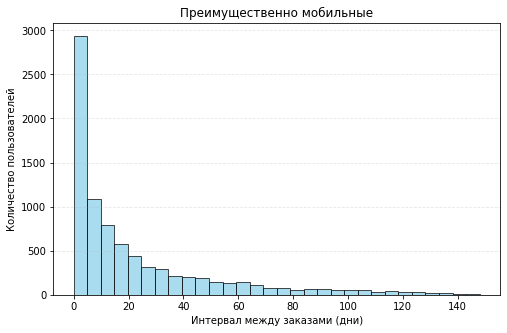

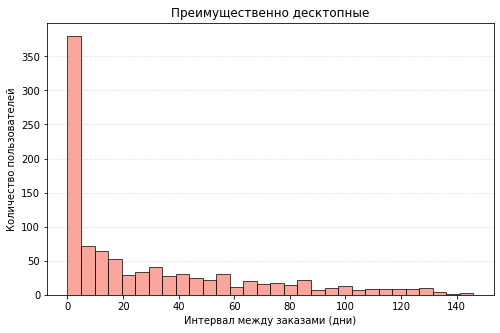

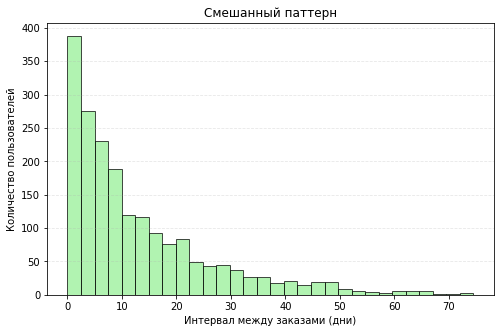

In [61]:
#данные по сегментам
mobile_data = user_stats[user_stats['device_segment'] == 'predominantly_mobile']['avg_interval_days']
desktop_data = user_stats[user_stats['device_segment'] == 'predominantly_desktop']['avg_interval_days']
mixed_data = user_stats[user_stats['device_segment'] == 'mixed_pattern']['avg_interval_days']

#гистограмма преимущественно мобильные
plt.figure(figsize=(8, 5))
plt.hist(mobile_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Преимущественно мобильные')
plt.xlabel('Интервал между заказами (дни)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#гистограмма преимущественно десктопные
plt.figure(figsize=(8, 5))
plt.hist(desktop_data, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Преимущественно десктопные')
plt.xlabel('Интервал между заказами (дни)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#гистограмма смешанный паттерн
plt.figure(figsize=(8, 5))
plt.hist(mixed_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Смешанный паттерн')
plt.xlabel('Интервал между заказами (дни)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


Распределения не являются нормальными. Из‑за сильной правосторонней асимметрии (длинного хвоста) среднее сильно завышается за счёт редких пользователей с очень большими интервалами. Медиана устойчива к таким выбросам и лучше отражает «типичного» пользователя в группе. Поэтому в грядущих тестах будем сравнивать медианы.

* Нулевая гипотеза: среднее время между заказами пользователей мобильных приложений аналогичное по сравнению с пользователями стационарных устройств или ниже.
* Альтернативная гипотеза: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств и это статистически значимо.

Приступим к статистическим тестам. Сначала сделаем тест Краскела‑Уоллиса, узнаем есть ли статистические различия между тремя группами.

In [62]:
#тест Краскела-Уоллиса
stat, p_value = kruskal(mobile, desktop, mixed)

print(f"Статистика Краскела-Уоллиса: H = {stat:.3f}")
print(f"P-value: {p_value:.3e}")

if p_value < 0.05:
    print("Вывод: Есть статистически значимые различия между хотя бы одной парой групп.")
else:
    print("Вывод: Нет оснований утверждать, что группы различаются (p ≥ 0.05).")



Статистика Краскела-Уоллиса: H = 21.471
P-value: 2.176e-05
Вывод: Есть статистически значимые различия между хотя бы одной парой групп.


Сравним попарно группы тестом Манна-Уитни. Этот тест подходит потому что распределение не нормальное, дисперсии неравные, разные размеры выборок.

In [63]:
groups = {
    'predominantly_mobile': mobile,
    'predominantly_desktop': desktop,
    'mixed_pattern': mixed
}

alpha = 0.05  

print(f" Попарные сравнения (альтернатива: mobile > other), alpha={alpha}\n")

pairs_to_check = [
    ('predominantly_mobile', 'predominantly_desktop'),
    ('predominantly_mobile', 'mixed_pattern')
]

for seg1, seg2 in pairs_to_check:
    data1 = groups[seg1]
    data2 = groups[seg2]
    
    
    stat, p_value = mannwhitneyu(data1, data2, alternative='greater')
    
    med_diff = np.median(data1) - np.median(data2)
    
    print(f"Сравнение: {seg1} vs {seg2}")
    print(f"  Медиана {seg1}: {np.median(data1):.2f} дн.")
    print(f"  Медиана {seg2}: {np.median(data2):.2f} дн.")
    print(f"  Разница медиан: {med_diff:.2f} дн.")
    print(f"  Статистика U: {stat:.1f}, P-value: {p_value:.3e}")
    
    if p_value < alpha:
        print(f"Нулевая гипотеза отвергается.")
        print(f"Вывод: Интервал между заказами у пользователей {seg1} статистически значимо выше, чем у {seg2}.")
    else:
        print(f"Нет оснований отвергать нулевую гипотезу.")
        print(f"Нельзя утверждать, что интервал у {seg1} выше, чем у {seg2} (различие может быть случайным).")
    
  


 Попарные сравнения (альтернатива: mobile > other), alpha=0.05

Сравнение: predominantly_mobile vs predominantly_desktop
  Медиана predominantly_mobile: 10.50 дн.
  Медиана predominantly_desktop: 13.14 дн.
  Разница медиан: -2.64 дн.
  Статистика U: 4032629.5, P-value: 8.664e-01
Нет оснований отвергать нулевую гипотезу.
Нельзя утверждать, что интервал у predominantly_mobile выше, чем у predominantly_desktop (различие может быть случайным).
Сравнение: predominantly_mobile vs mixed_pattern
  Медиана predominantly_mobile: 10.50 дн.
  Медиана mixed_pattern: 8.33 дн.
  Разница медиан: 2.17 дн.
  Статистика U: 8487566.0, P-value: 5.727e-06
Нулевая гипотеза отвергается.
Вывод: Интервал между заказами у пользователей predominantly_mobile статистически значимо выше, чем у mixed_pattern.


Результаты показали, что медианный интервал между заказами в сегменте predominantly_mobile (10.5 дней) статистически значимо ниже, чем в сегменте predominantly_desktop (13.14 дней)
p=0.87).
Изначальная гипотеза не подтвердилась. Типичный пользователь мобильного приложения совершает повторные покупки чаще, чем типичный пользователь десктопа.

##  Общий вывод и рекомендации

Информация о данных проекта:

Было три датафрейма:
* с информацией о заказах - orders 290849 строк и 14 столбцов
* с информацией о мероприятиях - events 22427 строк и 11 столбцов
* с курсом валюты - tenge 357 строк и 4 столбца
Был создан общий датафрейм:<br>
Сначала объединены orders и events.<br>
Затем были исключены выбросы (99 процентиль по полю revenue).<br>
Затем созданы столбцы revenue_rub, one_ticket_revenue_rub, month, season.<br>
В итоговом датасете merged_df 287962 строк и 30 столбцов.
* Дополнительно был создан отфильтрованный датасет df_autumn с данными за осень. В нем 168622  строк и 30 столбцов.

Опишем основные результаты анализа.

Какие мероприятия наиболее востребованы: <br>
* Летом одинаково много заказов по выставкам, концертам, стендапу и категории другое. Мало по спорту и елкам.
* Осенью наоборот много заказов по спорту и ёлкам.<br><br>
Возможные причины.<br>
* Летом аудитория охотнее выбирает мероприятия, совместимые с хорошей погодой и спонтанным досугом.
* Осенью предпочитают более запланированные мероприятия не под открытым небом (стадионы и прочее).
* Осенью стартуют спортивные сезоны, плюс заранее бронируют новогодние ёлки. Об этом также говорит анализ возрастного рейтинга мероприятий - летом больше заказов с рейтингом 18+, осенью больше заказов с рейтингом 0+ (те самые ёлки).<br><br>
Рекомендации для бизнеса:<br>
* Летом рекламировать выставки, концерты, стендап, осенью спорт и ёлки.
* На ёлки и топовые матчи ставить динамическое ценообразование - чем ближе к дате, тем дороже.
* Летом предлагать лёгкие варианты досуга, осенью - напоминать про планирование семейных событий.

Как изменился средний чек осенью по сравнению с летом: <br>
* Вырос в категориях выставки и стендап около 5%.
* Упал сильнее всего в концертах −35%, в театр и ёлках примерно −17 −18%, в другом и спорте примерно −2 −3%.<br><br>
Возможные причины.<br>
* Падение в концертах из‑за массовых недорогих событий, скидок или смещения спроса на бюджетные форматы.
* Стабильность в спорте и другом - сегменты менее чувствительны к сезонности, цены остаются на привычном уровне.
* Рост в выставках и стендапе - наценка за новизну и лимитированность, плюс осенью ниже конкуренция за внимание аудитории.
* Падение в ёлках и театре - эффект раннего бронирования, летом берут дорогие билеты, осенью дешёвые либо сезонная корректировка цен.<br><br>
Рекомендации для бизнеса:<br>
* Ввести динамическое ценообразование на ёлки и концерты: повышать цены на ранние продажи, ограничивать скидки в периоды высокого спроса.
* Активнее продвигать выставки и стендап это высокомаржинальные форматы с растущим средним чеком.
* Сегментировать предложения в концертах и театре (VIP, стандарт, эконом) и контролировать долю каждого сегмента, чтобы не снижать среднюю выручку.
* Проанализировать окупаемость скидок в концертной категории: если прирост объёмов не компенсирует снижение чека — пересмотреть промо‑стратегию.
* Учитывать сезонный перекос в выручке при планировании бюджета и KPI по категориям.

Какую информацию можно получить после изучения пользовательской активности::<br>
* Общее число заказов в день: тут мы видим 3 сентября, 1 октября, 31 октября довольно высокие показатели. Могут быть связаны с осенними каникулами, праздниками (например 5 сентября день учителя) и промоакциями.
* DAU: довольно стабильный показатель, есть мягкие всплески к выходным и перед крупными событиями, что гововорит о лояльной базе клиентов. 
* Среднее число заказов на пользователя: видим высокие показатели 3 сентября, 1 октября, 31 октября как и на первом графике с числом заказов в день. Они могут брать билеты на сембю или группу школьников либо реагировать на акции.
* Средняя стоимость одного билета: 3 сентября, 1 октября она самая низкая - возможно работали акции, но 31 октября стоимость билета не сильно отличается от остальных дней - возврат к среднему за счёт спроса на дорогие форматы.<br><br>
Рекомендации для бизнеса:<br>
* Закрепить даты в промо‑календаре (3 сентября, 1 октября, 31 октября) и запускать подборки и рассылки.
* Вводить пакетные предложения в предканикулярные периоды и повышать число билетов в заказе.
* Настроить динамическое ценообразование.
* Готовить сезонный контент, гайды «Куда сходить на каникулах», чек‑листы для группового бронирования.
* Регулярно сверять пики метрик - выявлять новые паттерны и корректировать промоакции.

Недельная активность пользователей:
 * Общее число заказов больше всего во вторник, меньше всего в воскресение. Возможно, во вторник выходят главные промо‑рассылки, подборки или новинки, срабатывает эффект «начала активной недели» после выходных. В воскресение снижение мотивации планировать досуг в конце недели или планы уже есть.
 * DAU в течение недели относительно стабильно. Возможно, устоявшаяся лояльная аудитория регулярно заходит на платформу, продукт работае без сбоев.
 * Среднее число заказов на пользователя больше всего во вторник, меньше всего в воскресение. Аналогично первому пункту - активнее покупают во вторник, а воскресение уже есть планы на досуг.
 * Средняя стоимость билета относительно одинакова все дни, кроме вторника. Тут либо специфика продаж в этот день - больше дорогих или дешёвых билетов, либо специально запускают промоакции во вторник.<br><br>
Рекомендации для бизнеса:<br>
* Во вторник запускать главные рассылки и баннеры, чтобы усилить пик продаж.
* Распределять топовые события по неделе, а не концентрировать только во вторник, чтобы выровнять выручку по дням.
* Проверить логику цены во вторник, если отклонение не запланировано, скорректировать стоимость; если это запланировано - оценить влияние на маржу.
* Стимулировать заказы в выходные - использовать промокоды, напоминания о «последних местах», подборки «на завтра».
* Использовать стабильный DAU и лояльность аудитории для маркетинговых акций.
* Сегментировать аудиторию по дням покупок, отдельно работать с «вторничными» и «выходными» пользователями.

Существуют ли среди регионов и партнёров явные лидеры по числу заказов и выручке с продажи билетов.
* Явный лидер среди регионов - Каменевский район, у него 31% от общего числа заказов, на втором месте Североярская область - 15%, на третьем - Широковская область 5%. Возможно, это большие города по аналогии с Москва, Питер, Казань и конечно в них происходит большое число мероприятий на которые покупают много билетов. В маленьких регионах мероприятий мало из-за не очень большого спроса, все едут в крупные города на мероприятия. 
* Рекомендация - сделать акцент именно на этих регионах, раз уж в них большой спрос. 
* Среди партнеров лидируют Билеты без проблем и Лови билет! Возможно, они монополисты или же у них лучшие условия для покупки билетов. Стоит более детально проанализировать партнеров но уже в рамках отдельного исследования. 

Статистические тесты по данным за осень:
1. Гипотеза о том, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств нашла подтверждение. Это можно объяснить тем, что люди часто использует смартфоны и те всегда под рукой. Можно мотивировать новых пользователей скачивать приложение и давать скидки на заказы именно в приложении, как это делает например Яндекс Путешествия.
2. Гипотеза о том, что среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств, не нашла подтверждения. Статистический тест показал, что пользователь мобильного приложения совершает повторные покупки чаще, чем типичный пользователь десктопа. Рекомендация аналогичная - сделать акцент на пользователях приложения.